**Question 24**

In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ladkevinkumar/group9-dsb/Gold 100years.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/Brent Oil.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/silver 100 years.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/swift_currency_tracker_all_reports.csv


,Currency_or_Economy,Global_Payment_Share,Unit
166,USD,51.14,%
167,EUR,21.30,%
168,GBP,6.54,%
169,JPY,3.53,%
170,CNY,3.10,%
171,CAD,3.03,%
172,HKD,1.76,%
173,AUD,1.61,%
174,SGD,1.23,%
175,CHF,1.07,%


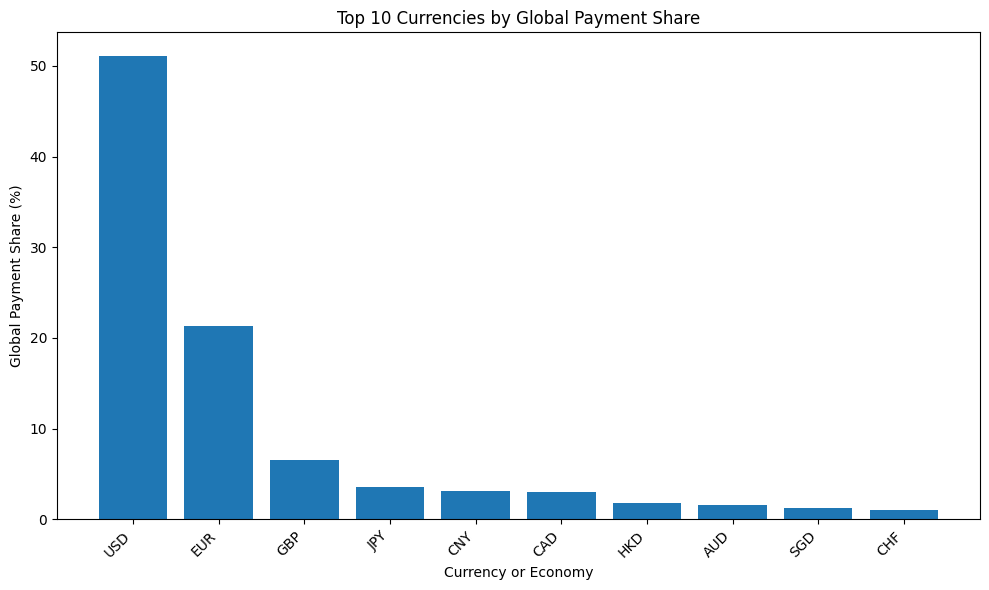

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

swift_df = pd.read_csv("/kaggle/input/datasets/ladkevinkumar/group9-dsb/swift_currency_tracker_all_reports.csv")

swift_df["data_month"] = pd.to_datetime(swift_df["data_month"], format="%B %Y", errors="coerce")

selected_month = swift_df["data_month"].max()

top10_df = swift_df[
    (swift_df["data_month"] == selected_month) &
    (swift_df["metric"] == "Global Payment Share")
].copy()

top10_df = top10_df.sort_values("value", ascending=False).head(10)

top10_table = top10_df[["currency_or_economy", "value", "unit"]]
top10_table.columns = ["Currency_or_Economy", "Global_Payment_Share", "Unit"]

display(top10_table)

top10_table.to_csv("q24_top10_currencies_selected_month.csv", index=False)

plt.figure(figsize=(10,6))
plt.bar(top10_table["Currency_or_Economy"], top10_table["Global_Payment_Share"])
plt.title("Top 10 Currencies by Global Payment Share")
plt.xlabel("Currency or Economy")
plt.ylabel("Global Payment Share (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("q24_top10_currencies_bar_chart.pdf")
plt.show()